# Part 3 — DBSCAN Clustering

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)

X_blobs,   _ = make_blobs(n_samples=300, centers=3, cluster_std=0.5, random_state=42)
X_moons,   _ = make_moons(n_samples=300, noise=0.07, random_state=42)
X_circles, _ = make_circles(n_samples=300, noise=0.05, factor=0.4, random_state=42)

sc = StandardScaler()
X_blobs   = sc.fit_transform(X_blobs)
X_moons   = sc.fit_transform(X_moons)
X_circles = sc.fit_transform(X_circles)

dataset_list = [('Blobs', X_blobs), ('Moons', X_moons), ('Circles', X_circles)]
COLORS       = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#8e44ad']


## Raw Datasets

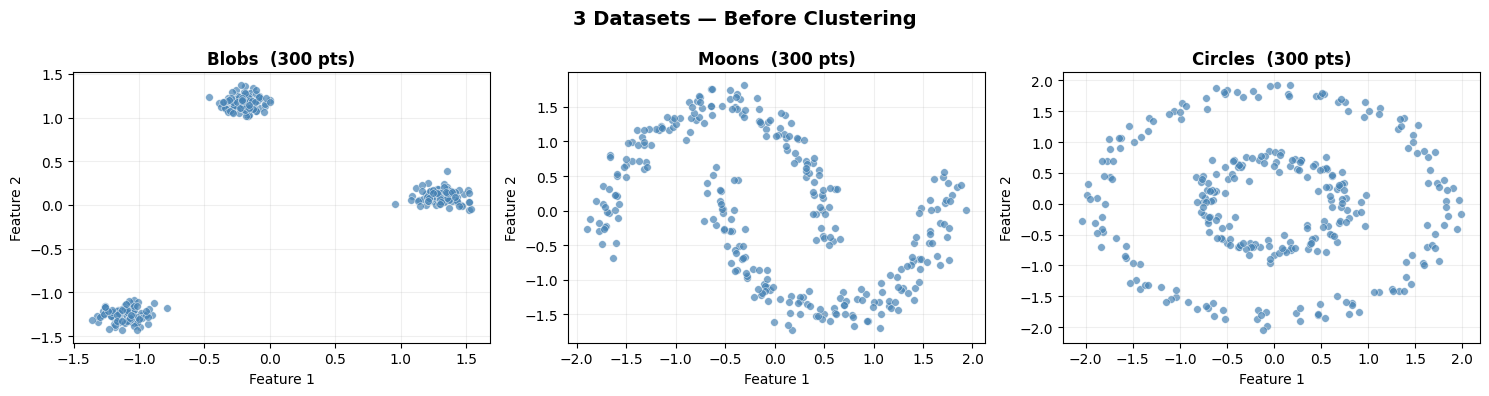

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, X) in zip(axes, dataset_list):
    ax.scatter(X[:,0], X[:,1], s=30, alpha=0.7, color='steelblue', edgecolors='white', linewidths=0.4)
    ax.set_title(f'{name}  ({len(X)} pts)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2'); ax.grid(True, alpha=0.2)
plt.suptitle('3 Datasets — Before Clustering', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## K-Distance Graphs — Choosing Epsilon

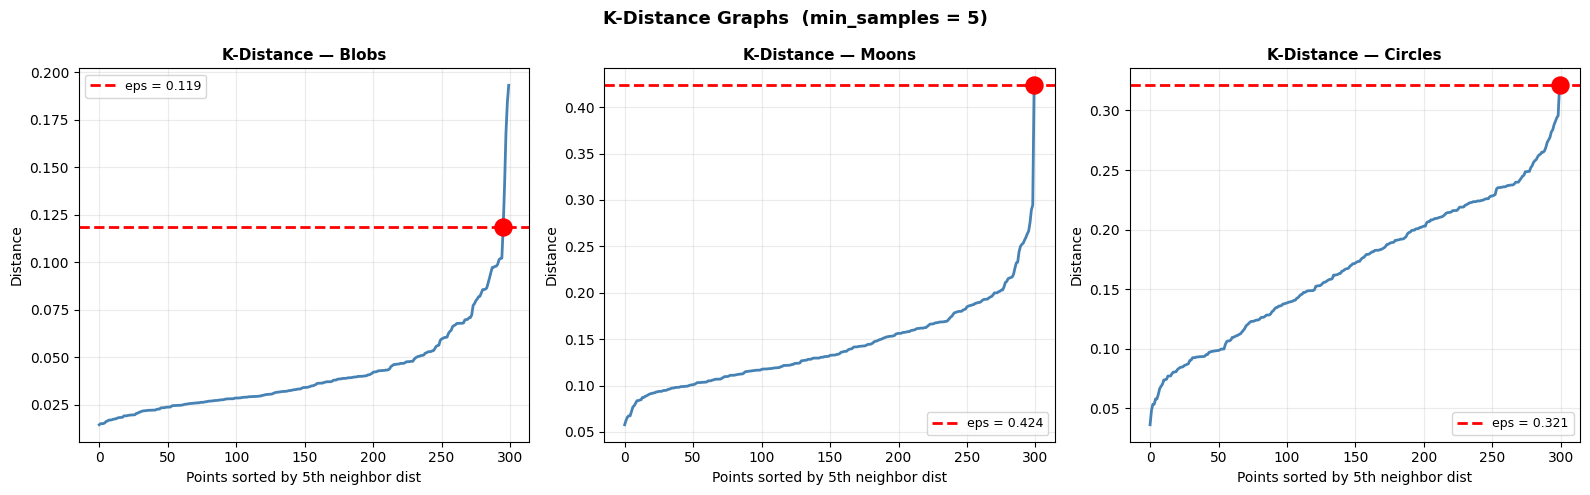

Suggested epsilon values:
  Blobs      : 0.119
  Moons      : 0.424
  Circles    : 0.321


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
suggested = {}
for ax, (name, X) in zip(axes, dataset_list):
    nbrs = NearestNeighbors(n_neighbors=5).fit(X)
    dists, _ = nbrs.kneighbors(X)
    k_dist   = np.sort(dists[:, -1])
    d2       = np.diff(np.diff(k_dist))
    eidx     = np.argmax(d2) + 2
    eps_val  = k_dist[eidx]
    suggested[name] = round(eps_val, 3)
    ax.plot(range(len(k_dist)), k_dist, color='steelblue', linewidth=2)
    ax.axhline(y=eps_val, color='red', linestyle='--', linewidth=2, label=f'eps = {eps_val:.3f}')
    ax.scatter([eidx], [eps_val], color='red', s=150, zorder=5)
    ax.set_title(f'K-Distance — {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Points sorted by 5th neighbor dist'); ax.set_ylabel('Distance')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
plt.suptitle('K-Distance Graphs  (min_samples = 5)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('Suggested epsilon values:')
for name, eps in suggested.items():
    print(f'  {name:<10} : {eps}')


## Apply All 3 Algorithms

In [4]:
dbscan_params = {
    'Blobs'  : {'eps': 0.35, 'min_samples': 5},
    'Moons'  : {'eps': 0.25, 'min_samples': 5},
    'Circles': {'eps': 0.35, 'min_samples': 5}
}

algorithms  = ['K-Means', 'Hierarchical', 'DBSCAN']
all_results = {}

for name, X in dataset_list:
    n_true = 3 if name == 'Blobs' else 2
    all_results[name] = {
        'K-Means'     : KMeans(n_clusters=n_true, init='k-means++', n_init=10, random_state=42).fit_predict(X),
        'Hierarchical': AgglomerativeClustering(n_clusters=n_true, linkage='ward').fit_predict(X),
        'DBSCAN'      : DBSCAN(eps=dbscan_params[name]['eps'],
                               min_samples=dbscan_params[name]['min_samples']).fit_predict(X)
    }

for name, X in dataset_list:
    lbl  = all_results[name]['DBSCAN']
    nc   = len(set(lbl) - {-1})
    nn   = np.sum(lbl == -1)
    print(f'{name}: DBSCAN found {nc} clusters, {nn} noise points')


Blobs: DBSCAN found 3 clusters, 0 noise points
Moons: DBSCAN found 2 clusters, 0 noise points
Circles: DBSCAN found 2 clusters, 0 noise points


## 3×3 Grid — Full Comparison

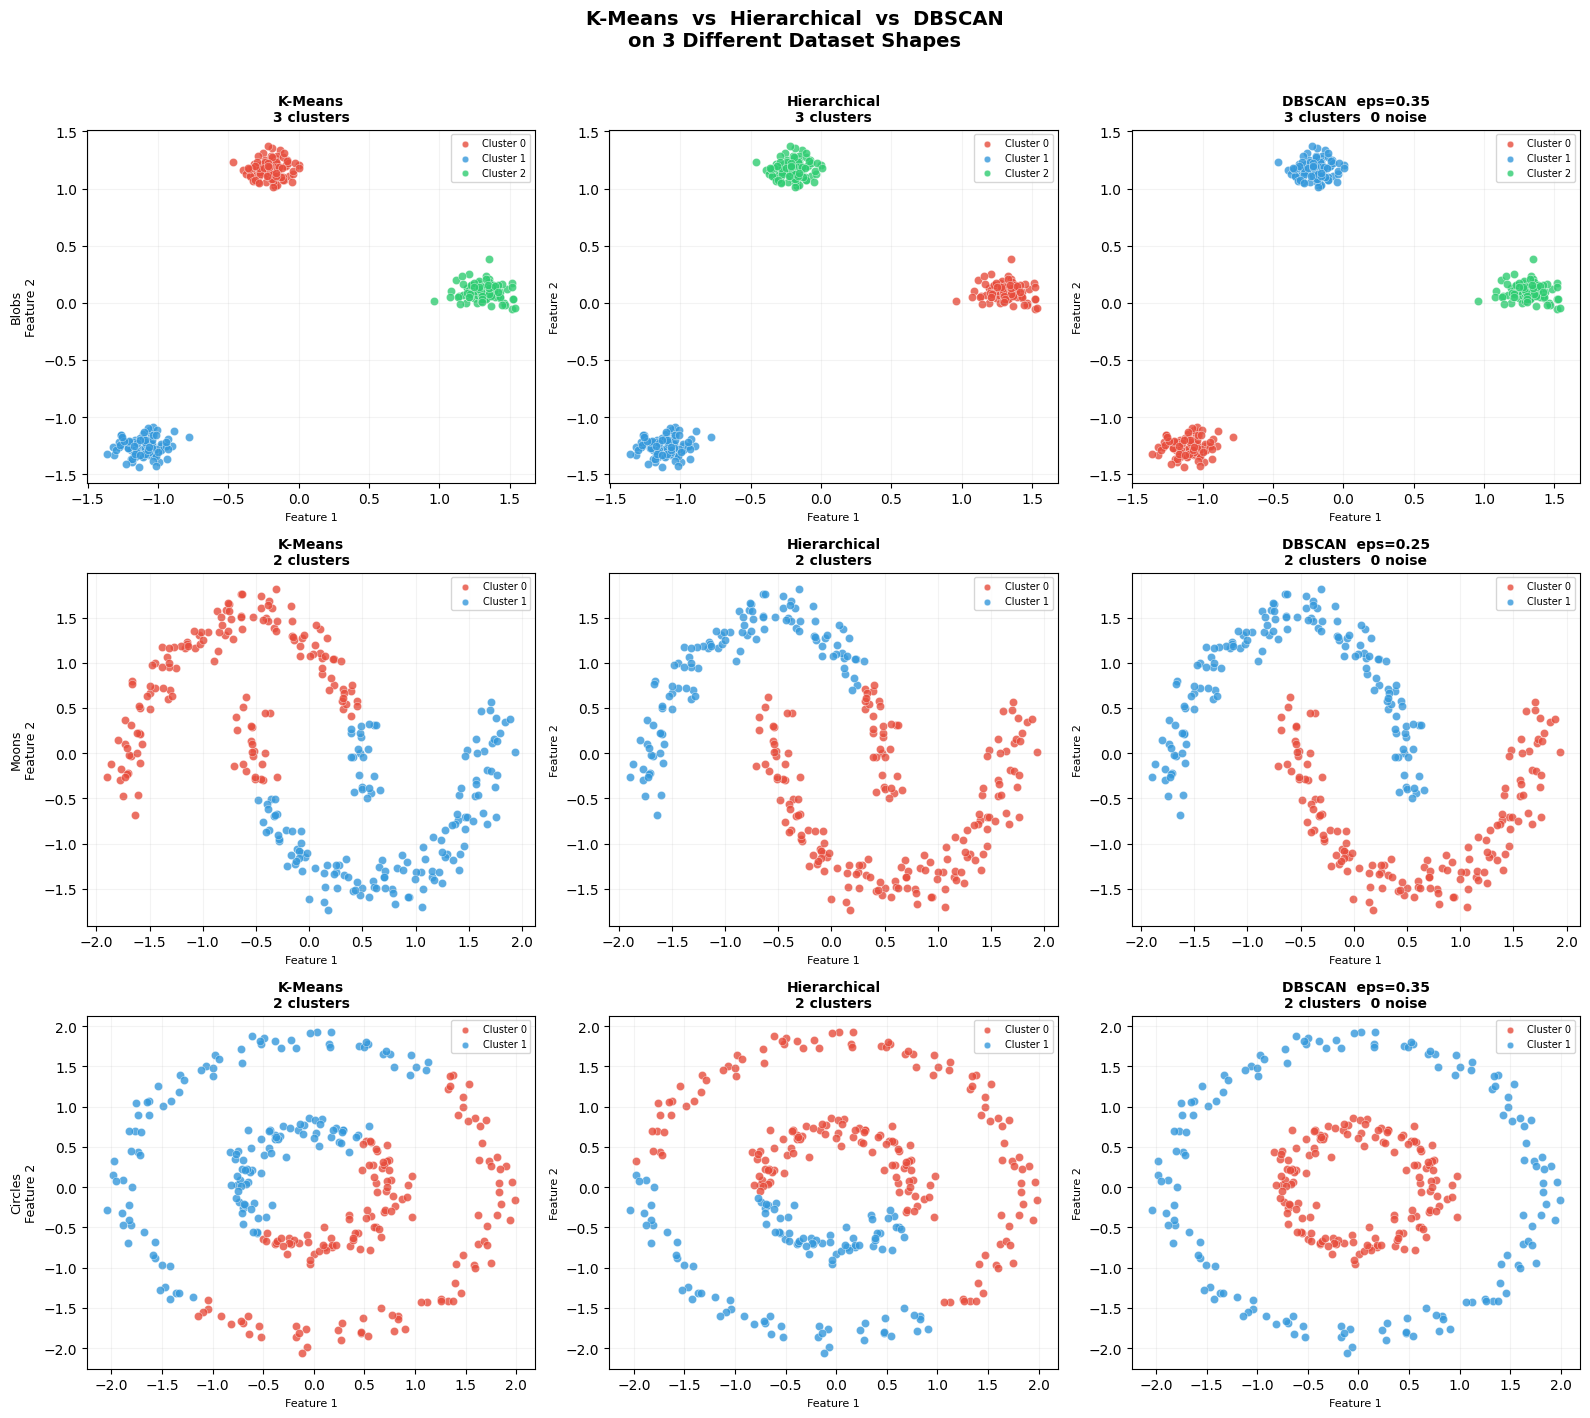

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for row, (dname, X) in enumerate(dataset_list):
    for col, algo in enumerate(algorithms):
        ax     = axes[row][col]
        labels = all_results[dname][algo]
        nc     = len(set(labels) - {-1})
        nn     = np.sum(labels == -1)
        for lbl in sorted(set(labels)):
            mask = labels == lbl
            if lbl == -1:
                ax.scatter(X[mask,0], X[mask,1], c='black', s=60, marker='x',
                           linewidths=1.5, alpha=0.7, label=f'Noise ({nn})')
            else:
                ax.scatter(X[mask,0], X[mask,1],
                           c=COLORS[lbl % len(COLORS)], s=35, alpha=0.80,
                           edgecolors='white', linewidths=0.3, label=f'Cluster {lbl}')
        if algo == 'DBSCAN':
            ax.set_title(f'{algo}  eps={dbscan_params[dname]["eps"]}\n{nc} clusters  {nn} noise',
                         fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{algo}\n{nc} clusters', fontsize=10, fontweight='bold')
        ax.set_xlabel('Feature 1', fontsize=8)
        ax.set_ylabel(f'{dname}\nFeature 2' if col == 0 else 'Feature 2', fontsize=9 if col==0 else 8)
        ax.grid(True, alpha=0.15)
        if nc <= 4:
            ax.legend(fontsize=7, loc='upper right', markerscale=0.8)

plt.suptitle('K-Means  vs  Hierarchical  vs  DBSCAN\non 3 Different Dataset Shapes',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


## DBSCAN Internals — Core, Border, Noise

Point Type Breakdown — Moons Dataset
  Core   : 290  (96.7%)
  Border : 10  (3.3%)
  Noise  : 0  (0.0%)


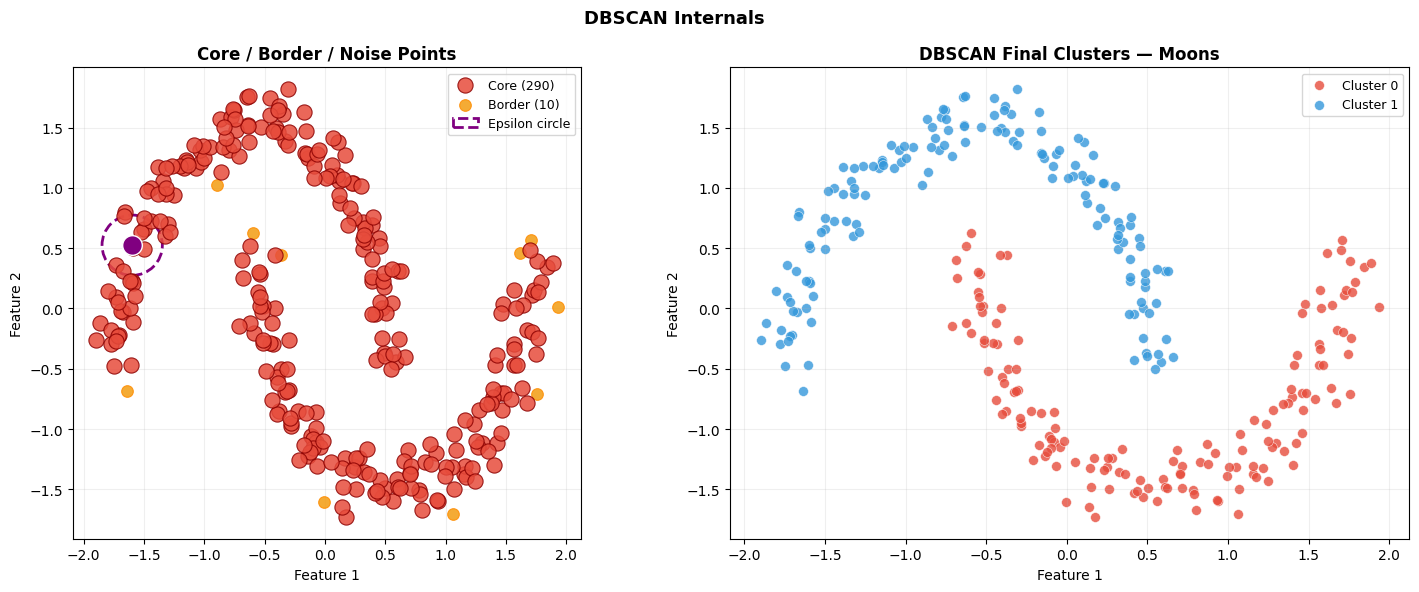

In [6]:
X_demo  = X_moons
db_demo = DBSCAN(eps=0.25, min_samples=5).fit(X_demo)
lab     = db_demo.labels_
core_idx= db_demo.core_sample_indices_

is_core   = np.zeros(len(X_demo), dtype=bool)
is_core[core_idx] = True
is_noise  = lab == -1
is_border = ~is_core & ~is_noise

print('Point Type Breakdown — Moons Dataset')
print(f'  Core   : {is_core.sum()}  ({is_core.sum()/len(X_demo)*100:.1f}%)')
print(f'  Border : {is_border.sum()}  ({is_border.sum()/len(X_demo)*100:.1f}%)')
print(f'  Noise  : {is_noise.sum()}  ({is_noise.sum()/len(X_demo)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
ax1.scatter(X_demo[is_core,0],   X_demo[is_core,1],   c='#e74c3c', s=120, alpha=0.85,
            label=f'Core ({is_core.sum()})',   edgecolors='darkred',   linewidths=0.8, zorder=3)
ax1.scatter(X_demo[is_border,0], X_demo[is_border,1], c='#f39c12', s=70,  alpha=0.85,
            label=f'Border ({is_border.sum()})', edgecolors='darkorange', linewidths=0.8, zorder=2)
if is_noise.sum() > 0:
    ax1.scatter(X_demo[is_noise,0],  X_demo[is_noise,1],  c='black',   s=100, marker='x',
                linewidths=2, label=f'Noise ({is_noise.sum()})', zorder=4)
sidx   = core_idx[len(core_idx)//2]
circle = plt.Circle((X_demo[sidx,0], X_demo[sidx,1]), 0.25,
                    fill=False, color='purple', linewidth=2, linestyle='--', label='Epsilon circle')
ax1.add_patch(circle)
ax1.scatter(X_demo[sidx,0], X_demo[sidx,1], c='purple', s=200, zorder=5, edgecolors='white')
ax1.set_title('Core / Border / Noise Points', fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature 1'); ax1.set_ylabel('Feature 2')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.2); ax1.set_aspect('equal')

ax2 = axes[1]
for lbl in sorted(set(lab)):
    mask = lab == lbl
    if lbl == -1:
        ax2.scatter(X_demo[mask,0], X_demo[mask,1], c='black', s=60, marker='x',
                    linewidths=1.5, label=f'Noise ({mask.sum()})')
    else:
        ax2.scatter(X_demo[mask,0], X_demo[mask,1], c=COLORS[lbl], s=50, alpha=0.80,
                    edgecolors='white', linewidths=0.4, label=f'Cluster {lbl}')
ax2.set_title('DBSCAN Final Clusters — Moons', fontsize=12, fontweight='bold')
ax2.set_xlabel('Feature 1'); ax2.set_ylabel('Feature 2')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.2)

plt.suptitle('DBSCAN Internals', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## Epsilon Sensitivity

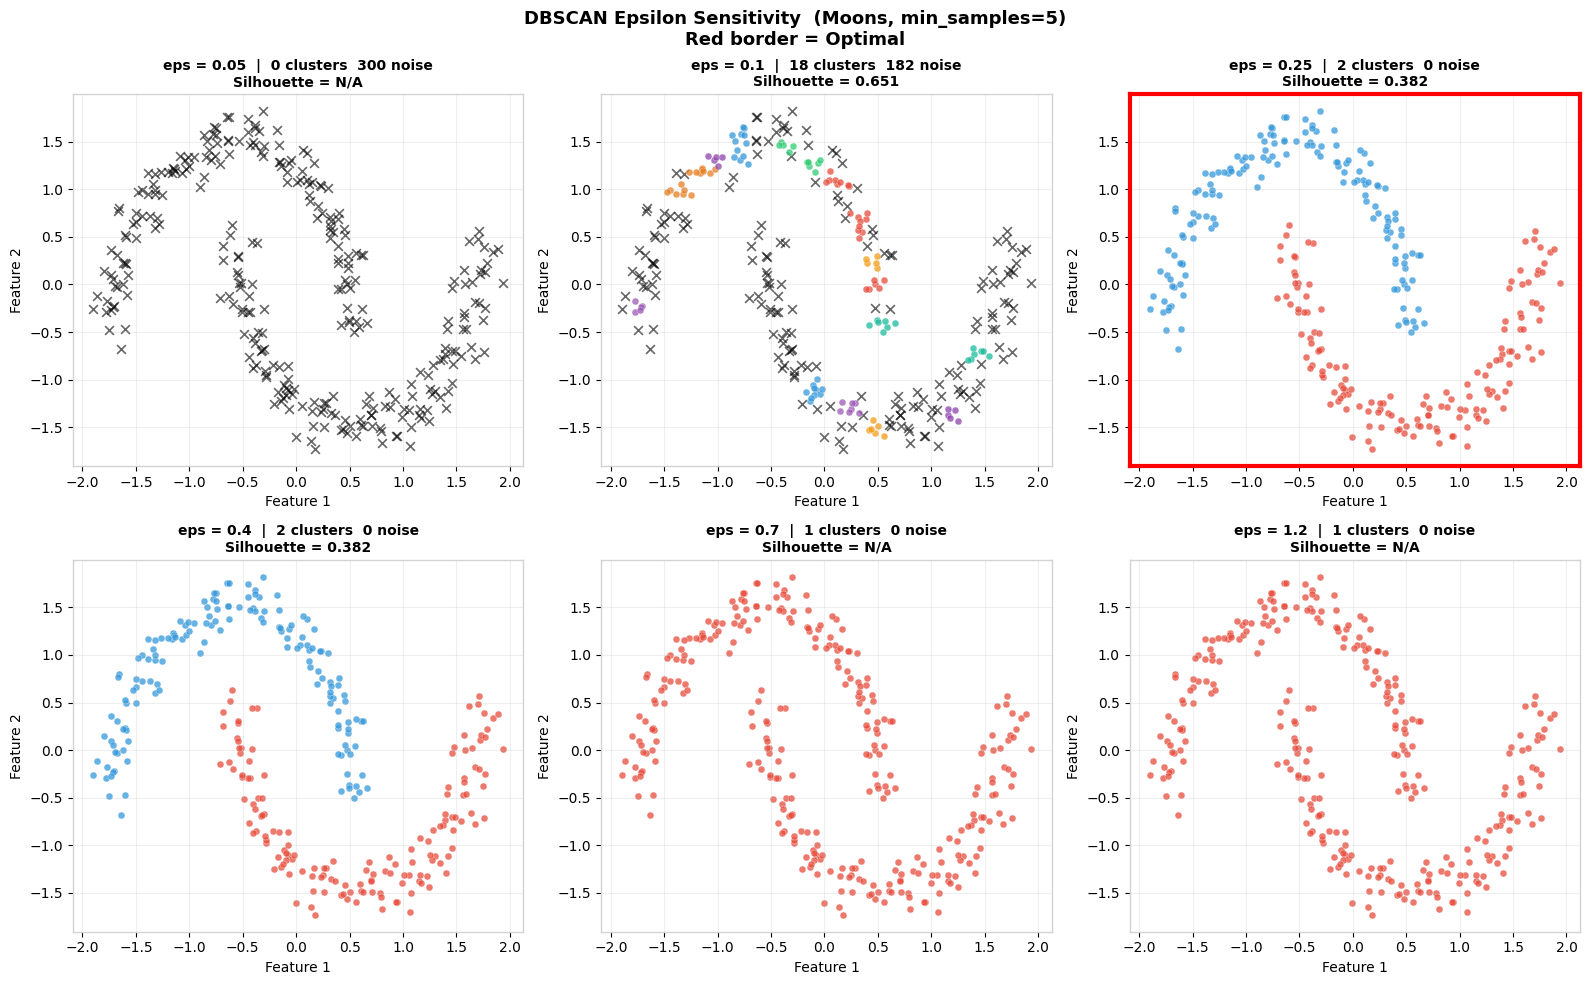

In [7]:
eps_vals = [0.05, 0.10, 0.25, 0.40, 0.70, 1.20]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

def safe_sil(X, lbl):
    v = lbl != -1
    return silhouette_score(X[v], lbl[v]) if len(set(lbl[v])) >= 2 else None

for i, ev in enumerate(eps_vals):
    ax  = axes[i]
    lbl = DBSCAN(eps=ev, min_samples=5).fit_predict(X_moons)
    nc  = len(set(lbl) - {-1}); nn = np.sum(lbl == -1)
    sil = safe_sil(X_moons, lbl)
    ss  = f'{sil:.3f}' if sil else 'N/A'
    for lb in sorted(set(lbl)):
        mask = lbl == lb
        if lb == -1:
            ax.scatter(X_moons[mask,0], X_moons[mask,1], c='black', s=40, marker='x', linewidths=1.2, alpha=0.6)
        else:
            ax.scatter(X_moons[mask,0], X_moons[mask,1], c=COLORS[lb % len(COLORS)],
                       s=25, alpha=0.75, edgecolors='white', linewidths=0.3)
    is_opt = abs(ev - 0.25) < 0.01
    for sp in ax.spines.values():
        sp.set_edgecolor('red' if is_opt else 'lightgray')
        sp.set_linewidth(3 if is_opt else 1)
    ax.set_title(f'eps = {ev}  |  {nc} clusters  {nn} noise\nSilhouette = {ss}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2'); ax.grid(True, alpha=0.2)

plt.suptitle('DBSCAN Epsilon Sensitivity  (Moons, min_samples=5)\nRed border = Optimal',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## Final Comparison Table

In [8]:
def safe_sil(X, lbl):
    v = lbl != -1
    return silhouette_score(X[v], lbl[v]) if len(set(lbl[v])) >= 2 else None

print('=' * 68)
print(f'  {"Dataset":<18} {"Algorithm":<16} {"Clusters":>9} {"Noise":>6} {"Silhouette":>12}')
print('-' * 68)
for dname, X in dataset_list:
    for algo in algorithms:
        lbl = all_results[dname][algo]
        nc  = len(set(lbl) - {-1}); nn = np.sum(lbl == -1)
        sil = safe_sil(X, lbl)
        ss  = f'{sil:.4f}' if sil else 'N/A'
        print(f'  {dname:<18} {algo:<16} {nc:>9} {nn:>6} {ss:>12}')
    print('-' * 68)
print()
print('Conclusion:')
print('  Blobs   -> All algorithms work   | Winner: K-Means (fastest)')
print('  Moons   -> K-Means & Hier fail   | Winner: DBSCAN')
print('  Circles -> K-Means & Hier fail   | Winner: DBSCAN')


  Dataset            Algorithm         Clusters  Noise   Silhouette
--------------------------------------------------------------------
  Blobs              K-Means                  3      0       0.9236
  Blobs              Hierarchical             3      0       0.9236
  Blobs              DBSCAN                   3      0       0.9236
--------------------------------------------------------------------
  Moons              K-Means                  2      0       0.4945
  Moons              Hierarchical             2      0       0.4534
  Moons              DBSCAN                   2      0       0.3824
--------------------------------------------------------------------
  Circles            K-Means                  2      0       0.3248
  Circles            Hierarchical             2      0       0.2892
  Circles            DBSCAN                   2      0       0.1546
--------------------------------------------------------------------

Conclusion:
  Blobs   -> All algorithms wor